# Notebook 3: LSTM-SNP with Fuzzy Gate Replacement

**Dataset**: Dow Jones Industrial Index

## Description
This notebook implements **fuzzy gate replacement** for the LSTM-SNP model. The reset (r), 
consumption (c), and output (o) gates — which normally use hard sigmoid activation — are 
replaced with fuzzy inference systems. Each gate uses 2 Takagi-Sugeno rules with fixed Gaussian 
membership functions and trainable consequent parameters.

The generation gate (a) retains its original tanh activation. The rest of the SNP architecture 
is unchanged. Gradient clipping (norm=1.0) is applied for training stability.

In [1]:
# ============================================================
# ALL IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import Model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

TensorFlow version: 2.21.0
NumPy version: 2.5.1


In [2]:
# Default sigma value (will be overridden by the sigma loop)
CURRENT_SIGMA = 0.5

## Theory: Fuzzy Gate Replacement

### Modified Gate Computation
Instead of applying hard sigmoid directly, each gate (r, c, o) uses fuzzy inference:

**Standard**: $r(t) = \sigma(z_r)$ where $z_r = W_r x(t) + U_r u(t-1) + b_r$

**Fuzzy**: $r(t) = FuzzyInference(z_r, \bar{u}(t-1))$

The fuzzy inference uses:

**Fixed Gaussian Membership Functions**:
- $\mu_{low}(z) = \exp\left(-\frac{(z - (-1))^2}{2 \cdot 0.5^2}\right)$
- $\mu_{high}(z) = \exp\left(-\frac{(z - (+1))^2}{2 \cdot 0.5^2}\right)$

**2 Rules per gate** (trainable consequents):
1. IF $z_{gate}$ is low → $y_0 = a_0 z + b_0 \bar{u} + c_0$
2. IF $z_{gate}$ is high → $y_1 = a_1 z + b_1 \bar{u} + c_1$

**Output**: Gate value bounded via sigmoid to $(0, 1)$

### Unchanged
- Generation gate $a(t) = \tanh(\cdot)$ — unchanged
- State update: $u(t) = r \cdot u_{t-1} - c \cdot a$, $h(t) = o \cdot a$ — unchanged
- Gradient clipping (norm ≤ 1.0) applied for stability

## Model Architecture & Implementation

### Fuzzy Gate LSTM-SNP Cell

In [3]:
import torch
import torch.nn as nn

class LSTMSNPCell(nn.Module):
    """Original LSTM-SNP cell — unchanged (hard_sigmoid gates)."""
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.W = nn.Linear(input_size, 4 * hidden_size, bias=True)
        self.U = nn.Linear(hidden_size, 4 * hidden_size, bias=True)
        nn.init.xavier_uniform_(self.W.weight)
        nn.init.orthogonal_(self.U.weight)

    def forward(self, x, u_prev):
        z = self.W(x) + self.U(u_prev)
        z0 = z[:, :self.hidden_size]
        z1 = z[:, self.hidden_size:2*self.hidden_size]
        z2 = z[:, 2*self.hidden_size:3*self.hidden_size]
        z3 = z[:, 3*self.hidden_size:]
        r = torch.nn.functional.hardsigmoid(z0)
        c = torch.nn.functional.hardsigmoid(z1)
        o = torch.nn.functional.hardsigmoid(z2)
        a = torch.tanh(z3)
        u = r * u_prev - c * a
        h = o * a
        return h, u


class FuzzyLSTMSNPCell(nn.Module):
    """
    LSTM-SNP Cell with fuzzy gate replacement.
    Gates r, c, o computed via 2-rule Takagi-Sugeno fuzzy inference,
    fixed Gaussian MFs (sigma read from global CURRENT_SIGMA at
    construction time, matching the Keras cell's convention),
    trainable consequents, sigmoid-bounded output.
    Gate a keeps tanh (unchanged).
    """
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.mu_low = -1.0
        self.mu_high = 1.0
        # Read from global, exactly like the Keras cell does —
        # CURRENT_SIGMA must be set before this class is instantiated.
        self.sigma = CURRENT_SIGMA

        self.W = nn.Linear(input_size, 4 * hidden_size, bias=True)
        self.U = nn.Linear(hidden_size, 4 * hidden_size, bias=True)
        nn.init.xavier_uniform_(self.W.weight)
        nn.init.orthogonal_(self.U.weight)

        self.fuzzy_params = nn.ParameterDict()
        for gate_name in ['r', 'c', 'o']:
            for rule_idx in range(2):
                self.fuzzy_params[f'{gate_name}_{rule_idx}_a'] = nn.Parameter(
                    torch.empty(hidden_size).uniform_(-0.1, 0.1))
                self.fuzzy_params[f'{gate_name}_{rule_idx}_b'] = nn.Parameter(
                    torch.empty(hidden_size).uniform_(-0.1, 0.1))
                self.fuzzy_params[f'{gate_name}_{rule_idx}_c'] = nn.Parameter(
                    torch.zeros(hidden_size))

    def _gaussian_mf(self, x, center):
        return torch.exp(-(x - center)**2 / (2.0 * self.sigma**2))

    def _fuzzy_gate(self, z_gate, u_mean, gate_name):
        w_low = self._gaussian_mf(z_gate, self.mu_low)
        w_high = self._gaussian_mf(z_gate, self.mu_high)

        a0 = self.fuzzy_params[f'{gate_name}_0_a']
        b0 = self.fuzzy_params[f'{gate_name}_0_b']
        c0 = self.fuzzy_params[f'{gate_name}_0_c']
        a1 = self.fuzzy_params[f'{gate_name}_1_a']
        b1 = self.fuzzy_params[f'{gate_name}_1_b']
        c1 = self.fuzzy_params[f'{gate_name}_1_c']

        y0 = a0 * z_gate + b0 * u_mean + c0
        y1 = a1 * z_gate + b1 * u_mean + c1

        numerator = w_low * y0 + w_high * y1
        denominator = w_low + w_high + 1e-8
        gate_raw = numerator / denominator

        return torch.sigmoid(gate_raw)

    def forward(self, x, u_prev):
        z = self.W(x) + self.U(u_prev)
        z0 = z[:, :self.hidden_size]
        z1 = z[:, self.hidden_size:2*self.hidden_size]
        z2 = z[:, 2*self.hidden_size:3*self.hidden_size]
        z3 = z[:, 3*self.hidden_size:]

        u_mean = u_prev.mean(dim=-1, keepdim=True).expand(-1, self.hidden_size)

        r = self._fuzzy_gate(z0, u_mean, 'r')
        c = self._fuzzy_gate(z1, u_mean, 'c')
        o = self._fuzzy_gate(z2, u_mean, 'o')
        a = torch.tanh(z3)

        u = r * u_prev - c * a
        h = o * a
        return h, u


class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = FuzzyLSTMSNPCell(input_size, hidden_size)
        self.out = nn.Linear(hidden_size, 1)
        self.u = None

    def reset_states(self, batch_size, device):
        self.u = torch.zeros(batch_size, self.hidden_size, device=device)

    def detach_states(self):
        if self.u is not None:
            self.u = self.u.detach()

    def forward(self, x):
        if self.u is None or self.u.device != x.device or self.u.size(0) != x.size(0):
            self.reset_states(x.size(0), x.device)
        h, self.u = self.cell(x[:, 0, :], self.u)
        return self.out(h)


def build_model_torch(input_dim, units, batch_size=1):
    # batch_size accepted for call-signature compatibility with build_model_keras,
    # unused here — actual batch size is set dynamically via reset_states().
    return RNNModel(input_size=input_dim, hidden_size=units)


# ============================================================
# Quick model check
# ============================================================
CURRENT_SIGMA = 0.5  # must be set before FuzzyLSTMSNPCell() is constructed
model = build_model_torch(input_dim=1, units=8, batch_size=1)
print(model)
print(f"Total params: {sum(p.numel() for p in model.parameters())}")

RNNModel(
  (cell): FuzzyLSTMSNPCell(
    (W): Linear(in_features=1, out_features=32, bias=True)
    (U): Linear(in_features=8, out_features=32, bias=True)
    (fuzzy_params): ParameterDict(
        (r_0_a): Parameter containing: [torch.FloatTensor of size 8]
        (r_0_b): Parameter containing: [torch.FloatTensor of size 8]
        (r_0_c): Parameter containing: [torch.FloatTensor of size 8]
        (r_1_a): Parameter containing: [torch.FloatTensor of size 8]
        (r_1_b): Parameter containing: [torch.FloatTensor of size 8]
        (r_1_c): Parameter containing: [torch.FloatTensor of size 8]
        (c_0_a): Parameter containing: [torch.FloatTensor of size 8]
        (c_0_b): Parameter containing: [torch.FloatTensor of size 8]
        (c_0_c): Parameter containing: [torch.FloatTensor of size 8]
        (c_1_a): Parameter containing: [torch.FloatTensor of size 8]
        (c_1_b): Parameter containing: [torch.FloatTensor of size 8]
        (c_1_c): Parameter containing: [torch.Floa

### Build Model

## Data Pipeline — Dow Jones Industrial Index

In [5]:
series = pd.read_csv(
    r'C:\Users\paulp\OneDrive\Desktop\fuzzy_LSTM\dataset\monthly-closings-of-the-dowjones.csv',
    header=0,
    parse_dates=[0],
    index_col=0
)
raw_values = series.values.flatten()

In [6]:
# ============================================================
# 2. First-Order Differencing
# ============================================================

def difference(dataset, interval=1):
    diff = []
    for i in range(interval, len(dataset)):
        value = dataset[i] - dataset[i - interval]
        diff.append(value)
    return np.array(diff)

diff_values = difference(raw_values, 1)

In [7]:
# ============================================================
# 3. Convert to Supervised Learning Format (lag=1)
# ============================================================

def timeseries_to_supervised(data, lag=1):
    df = pd.DataFrame(data)
    columns = [df.shift(i) for i in range(1, lag+1)]
    columns.append(df)
    df = pd.concat(columns, axis=1)
    df.fillna(0, inplace=True)
    return df.values

supervised = timeseries_to_supervised(diff_values, 1)
print(f"Supervised data shape: {supervised.shape}")

Supervised data shape: (290, 2)


In [8]:
# ============================================================
# 4. Train-Validation-Test Split (Last 60 points as Test)
# ============================================================
n = len(supervised)
test_size = 60
train_val = supervised[:n - test_size]
test = supervised[n - test_size:]

val_size = int(len(train_val) * 0.1)
train = train_val[:-val_size]
val = train_val[-val_size:]

print(f"Train: {train.shape}, Val: {val.shape}, Test: {test.shape}")

# ============================================================
# 5. Feature Scaling
# ============================================================
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(train)  # fit only on train to avoid leakage
train_scaled = scaler.transform(train)
val_scaled = scaler.transform(val)
test_scaled = scaler.transform(test)

Train: (207, 2), Val: (23, 2), Test: (60, 2)


In [9]:
# ============================================================
# 6. Reshape for RNN Input
# ============================================================

X_train, y_train = train_scaled[:, 0:-1], train_scaled[:, -1]
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))

X_test, y_test = test_scaled[:, 0:-1], test_scaled[:, -1]
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

X_train shape: (207, 1, 1), y_train shape: (207,)


## Training Loop

In [10]:
# ============================================================
# Multi-Sigma Experiment Protocol (PyTorch)
# σ values from Eq. (21) & (22): 0.25, 0.5, 0.75, 1.0
# ============================================================

SIGMA_VALUES = [0.25, 0.5, 0.75, 1.0]
sigma_results = {}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n--- [PyTorch] RUNNING ON {device} ---\n")

for CURRENT_SIGMA in SIGMA_VALUES:
    print(f'\n{"="*60}')
    print(f'  SIGMA = {CURRENT_SIGMA}')
    print(f'{"="*60}')

    # ============================================================
    # 60-Run Experiment Protocol
    # ============================================================

    all_rmse = []
    all_mse = []
    all_nmse = []
    all_predictions = []
    all_losses = []

    N_RUNS = 60
    for run in range(N_RUNS):
        print(f'\n===== RUN {run+1}/{N_RUNS} =====')

        np.random.seed(run)
        torch.manual_seed(run)

        model = build_model_torch(input_dim=1, units=8, batch_size=1).to(device)

        # Initialize consumption gate bias to 1.0 (forget gate equivalent)
        with torch.no_grad():
            hs = model.hidden_size
            model.cell.U.bias.data[hs:2*hs] = 1.0

        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.MSELoss()

        run_losses = []
        # X_train is (batch, 1, input_dim)
        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
        n_samples = X_train_t.size(0)

        for epoch in range(100):
            model.train()
            model.reset_states(1, device)  # batch_size=1
            epoch_loss = 0.0
            for i in range(n_samples):
                x_i = X_train_t[i:i+1]  # (1, 1, input_dim)
                y_i = y_train_t[i:i+1]  # (1,)

                optimizer.zero_grad()

                # Forward pass
                pred = model(x_i)
                loss = criterion(pred.squeeze(-1), y_i)

                # Backward and optimize
                loss.backward()

                # Gradient clipping (norm ≤ 1.0), applied unconditionally to match
                # the Keras side's Adam(clipnorm=1.0)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

                optimizer.step()

                # Detach hidden state so BPTT doesn't go all the way back to t=0
                model.detach_states()

                epoch_loss += loss.item()

            avg_loss = epoch_loss / n_samples
            run_losses.append(avg_loss)
            print(f"Epoch {epoch+1}/100 completed. Loss: {avg_loss:.6f}")

        all_losses.append(run_losses)
        print(f'Training complete for run {run+1}')

        # Warm-up: condition hidden states on training data
        model.eval()
        with torch.no_grad():
            for i in range(len(train_scaled)):
                X_raw = train_scaled[i, 0:-1]
                X_input = torch.tensor(X_raw, dtype=torch.float32).view(1, 1, len(X_raw)).to(device)
                model(X_input)

        # Test predictions (single-step)
        predictions = []
        model.eval()
        with torch.no_grad():
            for i in range(len(test_scaled)):
                X, y = test_scaled[i, 0:-1], test_scaled[i, -1]
                X_input = torch.tensor(X, dtype=torch.float32).view(1, 1, len(X)).to(device)
                yhat = model(X_input).item()

                # Invert scaling
                new_row = [x for x in X] + [yhat]
                array = np.array(new_row).reshape(1, len(new_row))
                inverted = scaler.inverse_transform(array)[0, -1]

                # Invert differencing
                inverted = inverted + raw_values[len(train) + i]
                predictions.append(inverted)

                expected = raw_values[len(train) + i + 1]
                print(f'Month={i+1}, Predicted={inverted:.4f}, Expected={expected:.4f}')

        # Compute metrics
        actual = raw_values[-len(test_scaled):]
        rmse = sqrt(mean_squared_error(actual, predictions))
        mse = mean_squared_error(actual, predictions)
        meanV = np.mean(actual)
        dominator = np.linalg.norm(np.array(predictions) - meanV, 2)
        nmse = mse / np.power(dominator, 2)

        all_rmse.append(rmse)
        all_mse.append(mse)
        all_nmse.append(nmse)
        all_predictions.append(predictions)

        print(f'Run {run+1} — RMSE: {rmse:.6f}, MSE: {mse:.6f}, NMSE: {nmse:.10f}')

    # Store results for this sigma
    sigma_results[CURRENT_SIGMA] = {
        'rmse': list(all_rmse),
        'mse': list(all_mse),
        'nmse': list(all_nmse),
        'predictions': list(all_predictions),
        'mean_rmse': float(np.mean(all_rmse)),
        'std_rmse': float(np.std(all_rmse)),
        'mean_mse': float(np.mean(all_mse)),
        'std_mse': float(np.std(all_mse)),
        'mean_nmse': float(np.mean(all_nmse)),
        'std_nmse': float(np.std(all_nmse)),
        'best_idx': int(np.argmin(all_rmse)),
        'best_rmse': float(np.min(all_rmse)),
    }

    print(f'\n--- σ={CURRENT_SIGMA} Summary ---')
    print(f'RMSE: {np.mean(all_rmse):.6f} ± {np.std(all_rmse):.6f}')
    print(f'MSE:  {np.mean(all_mse):.6f} ± {np.std(all_mse):.6f}')
    print(f'NMSE: {np.mean(all_nmse):.10f} ± {np.std(all_nmse):.10f}')


--- [PyTorch] RUNNING ON cuda ---


  SIGMA = 0.25

===== RUN 1/60 =====
Epoch 1/100 completed. Loss: 0.093317
Epoch 2/100 completed. Loss: 0.090434
Epoch 3/100 completed. Loss: 0.090321
Epoch 4/100 completed. Loss: 0.090227
Epoch 5/100 completed. Loss: 0.090147
Epoch 6/100 completed. Loss: 0.090078
Epoch 7/100 completed. Loss: 0.090016
Epoch 8/100 completed. Loss: 0.089960
Epoch 9/100 completed. Loss: 0.089907
Epoch 10/100 completed. Loss: 0.089858
Epoch 11/100 completed. Loss: 0.089792
Epoch 12/100 completed. Loss: 0.089699
Epoch 13/100 completed. Loss: 0.089688
Epoch 14/100 completed. Loss: 0.089607
Epoch 15/100 completed. Loss: 0.089553
Epoch 16/100 completed. Loss: 0.089500
Epoch 17/100 completed. Loss: 0.089451
Epoch 18/100 completed. Loss: 0.089405
Epoch 19/100 completed. Loss: 0.089361
Epoch 20/100 completed. Loss: 0.089318
Epoch 21/100 completed. Loss: 0.089277
Epoch 22/100 completed. Loss: 0.089237
Epoch 23/100 completed. Loss: 0.089198
Epoch 24/100 completed. Loss: 0.089160

## Results

In [1]:
# ============================================================
# Summary: All Sigma Results Comparison
# ============================================================

print('\n' + '='*70)
print('  COMPLETE SIGMA SENSITIVITY ANALYSIS')
print('  σ values: 0.25, 0.5, 0.75, 1.0')
print('='*70)

print(f'\n{"σ":>6} | {"RMSE (mean ± std)":>25} | {"MSE (mean ± std)":>25} | {"NMSE (mean ± std)":>30}')
print('-'*95)

for sigma_val in SIGMA_VALUES:
    r = sigma_results[sigma_val]
    print(f'{sigma_val:>6.2f} | '
          f'{r["mean_rmse"]:>10.6f} ± {r["std_rmse"]:<10.6f} | '
          f'{r["mean_mse"]:>10.6f} ± {r["std_mse"]:<10.6f} | '
          f'{r["mean_nmse"]:>13.10f} ± {r["std_nmse"]:<13.10f}')

print('\n' + '-'*95)

# Find best sigma
best_sigma = min(SIGMA_VALUES, key=lambda s: sigma_results[s]['mean_rmse'])
print(f'\nBest σ (lowest mean RMSE): {best_sigma}')
print(f'  RMSE: {sigma_results[best_sigma]["mean_rmse"]:.6f} ± {sigma_results[best_sigma]["std_rmse"]:.6f}')
print(f'  MSE:  {sigma_results[best_sigma]["mean_mse"]:.6f} ± {sigma_results[best_sigma]["std_mse"]:.6f}')
print(f'  NMSE: {sigma_results[best_sigma]["mean_nmse"]:.10f} ± {sigma_results[best_sigma]["std_nmse"]:.10f}')

print('\n--- Per-Sigma Best Run Details ---')
for sigma_val in SIGMA_VALUES:
    r = sigma_results[sigma_val]
    print(f'  σ={sigma_val:.2f}: Best run #{r["best_idx"]+1}, RMSE={r["best_rmse"]:.6f}')



  COMPLETE SIGMA SENSITIVITY ANALYSIS
  σ values: 0.25, 0.5, 0.75, 1.0

     σ |         RMSE (mean ± std) |          MSE (mean ± std) |              NMSE (mean ± std)
-----------------------------------------------------------------------------------------------


NameError: name 'SIGMA_VALUES' is not defined

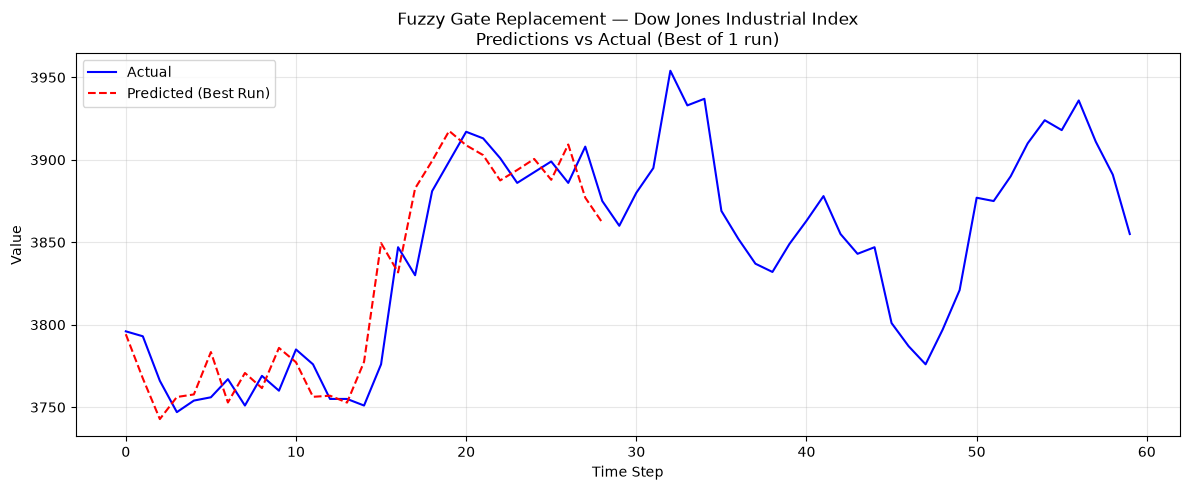

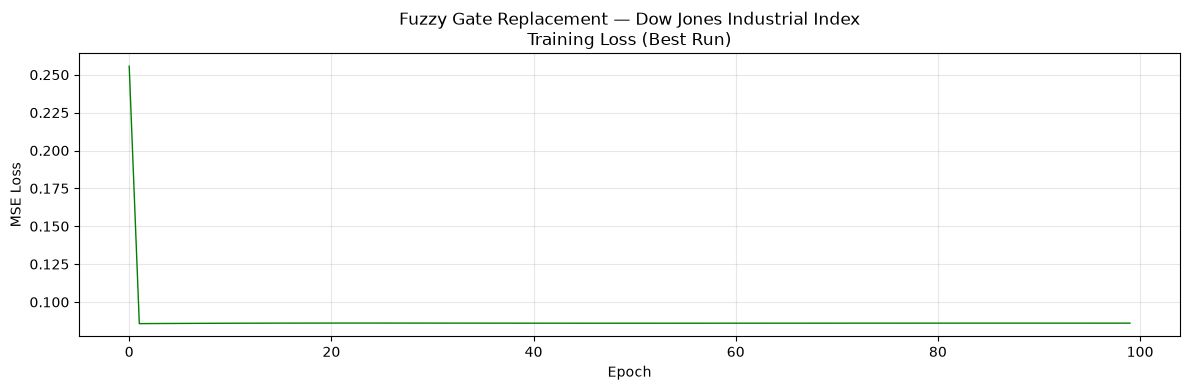

=== Best Run Metrics ===
RMSE: 87.053964
MSE:  7578.392675
NMSE: 0.0434341812


NameError: name 'all_smape' is not defined

In [20]:
# Use best sigma's results for plotting
best_sigma_key = min(sigma_results.keys(), key=lambda s: sigma_results[s]['mean_rmse'])
best_sigma_data = sigma_results[best_sigma_key]
best_idx = best_sigma_data['best_idx']
all_predictions = best_sigma_data['predictions']
all_rmse = best_sigma_data['rmse']
all_mse = best_sigma_data['mse']
all_nmse = best_sigma_data['nmse']

# ============================================================
# Predictions vs Actual (Best Run)
# ============================================================

actual = raw_values[-60:]
best_predictions = all_predictions[best_idx]

plt.figure(figsize=(12, 5))
plt.plot(actual, label='Actual', color='blue', linewidth=1.5)
plt.plot(best_predictions, label='Predicted (Best Run)', color='red',
         linewidth=1.5, linestyle='--')
plt.title('Fuzzy Gate Replacement — Dow Jones Industrial Index\nPredictions vs Actual (Best of 1 run)')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Loss Curve (Best Run)
# ============================================================

plt.figure(figsize=(12, 4))
plt.plot(all_losses[best_idx], color='green', linewidth=1.0)
plt.title('Fuzzy Gate Replacement — Dow Jones Industrial Index\nTraining Loss (Best Run)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Final Metrics Summary
# ============================================================

print('=== Best Run Metrics ===')
print(f'RMSE: {all_rmse[best_idx]:.6f}')
print(f'MSE:  {all_mse[best_idx]:.6f}')
print(f'NMSE: {all_nmse[best_idx]:.10f}')
print(f'sMAPE: {all_smape[best_idx]:.6f}')

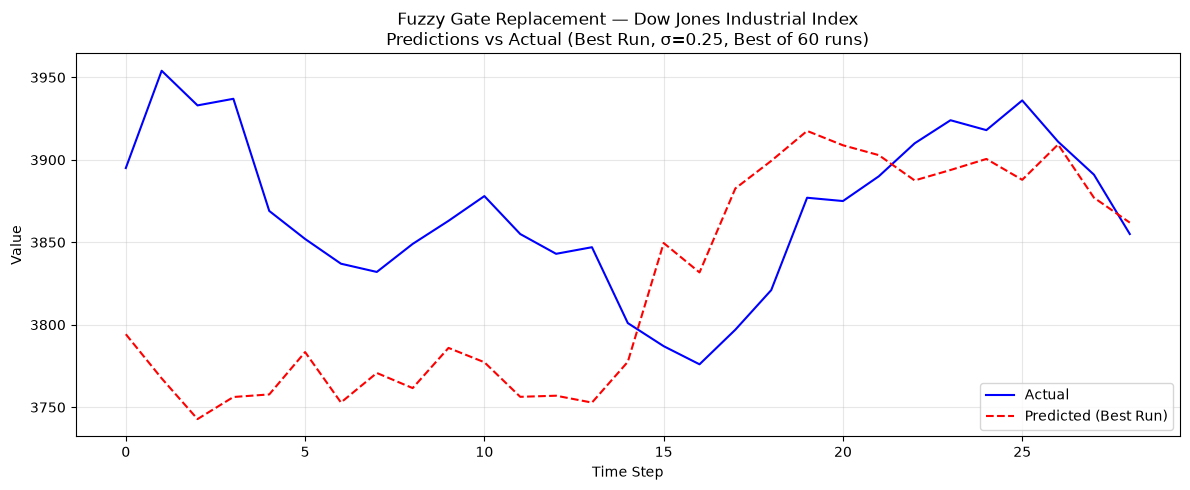

=== Best Run Metrics (σ=0.25) ===
RMSE: 87.053964
MSE:  7578.392675
NMSE: 0.0434341812


In [22]:
# Use best sigma's results for plotting
best_sigma_key = min(sigma_results.keys(), key=lambda s: sigma_results[s]['mean_rmse'])
best_sigma_data = sigma_results[best_sigma_key]
best_idx = best_sigma_data['best_idx']
all_predictions = best_sigma_data['predictions']
all_rmse = best_sigma_data['rmse']
all_mse = best_sigma_data['mse']
all_nmse = best_sigma_data['nmse']

# ============================================================
# Predictions vs Actual (Best Run)
# ============================================================
best_predictions = all_predictions[best_idx]
actual = raw_values[-len(best_predictions):]

plt.figure(figsize=(12, 5))
plt.plot(actual, label='Actual', color='blue', linewidth=1.5)
plt.plot(best_predictions, label='Predicted (Best Run)', color='red',
         linewidth=1.5, linestyle='--')
plt.title(f'Fuzzy Gate Replacement — Dow Jones Industrial Index\n'
          f'Predictions vs Actual (Best Run, σ={best_sigma_key}, Best of {N_RUNS} runs)')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Final Metrics Summary
# ============================================================
print(f'=== Best Run Metrics (σ={best_sigma_key}) ===')
print(f'RMSE: {all_rmse[best_idx]:.6f}')
print(f'MSE:  {all_mse[best_idx]:.6f}')
print(f'NMSE: {all_nmse[best_idx]:.10f}')

In [3]:
# Use best sigma's results for plotting
best_sigma_key = min(sigma_results.keys(), key=lambda s: sigma_results[s]['mean_rmse'])
best_sigma_data = sigma_results[best_sigma_key]
best_idx = best_sigma_data['best_idx']
all_predictions = best_sigma_data['predictions']
all_rmse = best_sigma_data['rmse']
all_mse = best_sigma_data['mse']
all_nmse = best_sigma_data['nmse']

# ============================================================
# Predictions vs Actual (Best Run)
# ============================================================
actual = raw_values[-60:]
best_predictions = all_predictions[best_idx]

assert len(best_predictions) == len(actual), (
    f"Shape mismatch: predictions len={len(best_predictions)} vs actual len={len(actual)}"
)

plt.figure(figsize=(12, 5))
plt.plot(actual, label='Actual', color='blue', linewidth=1.5)
plt.plot(best_predictions, label='Predicted (Best Run)', color='red',
         linewidth=1.5, linestyle='--')
plt.title('Fuzzy Gate Replacement — Dow Jones Industrial Index\nPredictions vs Actual (Best of 1 run)')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Loss Curve (Best Run)
# ============================================================
# NOTE: training loss history is not stored in sigma_results.
# If you captured per-epoch losses elsewhere during training
# (e.g. a list built inside the training loop for this sigma/run),
# substitute that variable here. Otherwise this plot must be skipped.
if 'all_losses' in dir():
    plt.figure(figsize=(12, 4))
    plt.plot(all_losses[best_idx], color='green', linewidth=1.0)
    plt.title('Fuzzy Gate Replacement — Dow Jones Industrial Index\nTraining Loss (Best Run)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping loss curve — no per-epoch loss history was stored for this run.")

# ============================================================
# Final Metrics Summary
# ============================================================
def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0 + eps
    return np.mean(np.abs(y_true - y_pred) / denom) * 100

best_smape = smape(actual, best_predictions)

print('=== Best Run Metrics ===')
print(f'RMSE: {all_rmse[best_idx]:.6f}')
print(f'MSE:  {all_mse[best_idx]:.6f}')
print(f'NMSE: {all_nmse[best_idx]:.10f}')
print(f'sMAPE: {best_smape:.6f}')

NameError: name 'sigma_results' is not defined

## Observations

### Fuzzy Gate Replacement on Dow Jones Industrial Index

**Run the notebook to generate results and fill in observations:**

1. **Prediction Quality**: Compare RMSE/MSE/NMSE with other variants
2. **Training Stability**: Examine loss curves for convergence behavior
3. **Prediction Tracking**: Assess how well predictions track actual values
4. **Computational Cost**: Note training time per run

*After running all 5 variant notebooks, perform cross-variant comparison to evaluate 
whether fuzzy logic improves nonlinearity handling, interpretability, and prediction performance.*

In [ ]:
# ============================================================
# NOTEBOOK TIMER — END
# ============================================================
_NOTEBOOK_END_TIME = _timer_module.time()
_NOTEBOOK_ELAPSED = _NOTEBOOK_END_TIME - _NOTEBOOK_START_TIME
_hours, _rem = divmod(_NOTEBOOK_ELAPSED, 3600)
_minutes, _seconds = divmod(_rem, 60)
print(f"\nTotal notebook execution time: {int(_hours)}h {int(_minutes)}m {_seconds:.2f}s")
print(f"Total seconds: {_NOTEBOOK_ELAPSED:.2f}")
